<a href="https://colab.research.google.com/github/deduwkaa/Theory_and_Applications_of_Digital_Signal_Processing/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

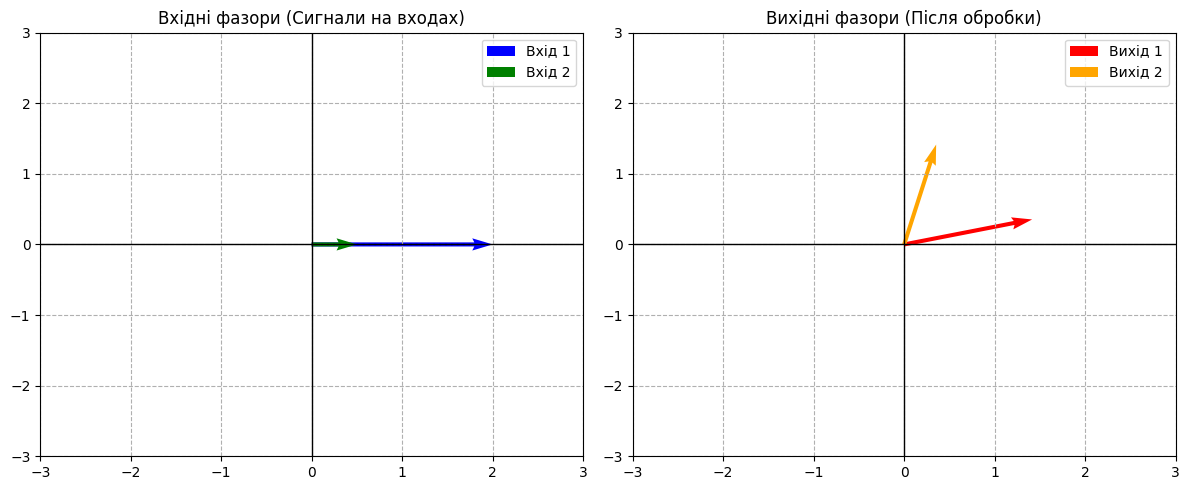

In [ ]:
import numpy as np
import cmath
import matplotlib.pyplot as plt

# 1. Визначаємо функцію для малювання
def plot_phasors(E1, E2, Eout1, Eout2):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    def add_vector(axis, complex_num, label, color):
        # Малюємо стрілку від (0,0) до (Re, Im)
        axis.quiver(0, 0, complex_num.real, complex_num.imag,
                    angles='xy', scale_units='xy', scale=1, color=color, label=label)

    # Малюємо вхідні сигнали
    add_vector(ax[0], E1, 'Вхід 1', 'blue')
    add_vector(ax[0], E2, 'Вхід 2', 'green')
    ax[0].set_title("Вхідні фазори (Сигнали на входах)")

    # Малюємо результати сплітера
    add_vector(ax[1], Eout1, 'Вихід 1', 'red')
    add_vector(ax[1], Eout2, 'Вихід 2', 'orange')
    ax[1].set_title("Вихідні фазори (Після обробки)")

    for a in ax:
        # Автоматично підбираємо масштаб, щоб стрілки було видно
        limit = max(abs(E1), abs(E2), abs(Eout1), abs(Eout2), 0.1) * 1.5
        a.set_xlim(-limit, limit)
        a.set_ylim(-limit, limit)
        a.axhline(0, color='black', lw=1)
        a.axvline(0, color='black', lw=1)
        a.grid(True, linestyle='--')
        a.legend()

    plt.tight_layout()
    plt.show()

# 2. ОСНОВНА ЧАСТИНА

# Вхідні дані
k = 0.5            # Коефіцієнт 50/50
a1, phi1 = 2, 0    # Вхід 1: Амплітуда 1, Фаза 0 градусів
a2, phi2 = 0.5, 0   # Вхід 2: Амплітуда 1, Фаза 90 градусів

# Створюємо комплексні числа
E1 = cmath.rect(a1, np.radians(phi1))
E2 = cmath.rect(a2, np.radians(phi2))

# Розрахунок за матрицею сплітера
t = np.sqrt(k)
r = np.sqrt(1 - k) * 1j
E_out1 = t * E1 + r * E2
E_out2 = r * E1 + t * E2

# 3. ВИКЛИК ВІЗУАЛІЗАЦІЇ
plot_phasors(E1, E2, E_out1, E_out2)